*UCI Online Retail II — UK gift retailer, Dec 2009 to Dec 2011. Covers revenue trends, RFM segmentation, cohort retention, and simple CLV. Cleaned in Python, analysed in DuckDB SQL.*

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
path = "/content/drive/MyDrive/Data Projects/online_retail_II.xlsx"

df_09 = pd.read_excel(path, sheet_name="Year 2009-2010")
df_10 = pd.read_excel(path, sheet_name="Year 2010-2011")

In [4]:
print(f"df_09", df_09.shape)
print(f"df_10", df_10.shape)

df_09 (525461, 8)
df_10 (541910, 8)


In [5]:
df = pd.concat([df_09, df_10], ignore_index=True)
df.shape

(1067371, 8)

In [6]:
df=df.drop_duplicates().reset_index(drop=True)
df.shape

(1033036, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1033036 entries, 0 to 1033035
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1033036 non-null  object        
 1   StockCode    1033036 non-null  object        
 2   Description  1028761 non-null  object        
 3   Quantity     1033036 non-null  int64         
 4   InvoiceDate  1033036 non-null  datetime64[ns]
 5   Price        1033036 non-null  float64       
 6   Customer ID  797885 non-null   float64       
 7   Country      1033036 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 63.1+ MB


In [8]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4275
Quantity,0
InvoiceDate,0
Price,0
Customer ID,235151
Country,0


*Dropped ~23% of rows — 235k missing Customer ID (no way to track behaviour), 4k missing Description. Rows with either null removed*

In [9]:
df = df.dropna(subset=['Customer ID', 'Description']).reset_index(drop=True)

df['Customer ID']=df['Customer ID'].astype(int)
df['Country']=df['Country'].astype('category')

In [10]:
print(df.isnull().sum())
print(df.info())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797885 entries, 0 to 797884
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      797885 non-null  object        
 1   StockCode    797885 non-null  object        
 2   Description  797885 non-null  object        
 3   Quantity     797885 non-null  int64         
 4   InvoiceDate  797885 non-null  datetime64[ns]
 5   Price        797885 non-null  float64       
 6   Customer ID  797885 non-null  int64         
 7   Country      797885 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 43.4+ MB
None


*Deleted POST, M, D, ADJUST, DOT, CRUK. These are just fees/adjustments, not real sales. Kept PADS because it’s a real item*

In [11]:
service_fees = df[df['StockCode'].str.isalpha() == True]
print(service_fees[['StockCode', 'Description']].drop_duplicates())

       StockCode                          Description
89          POST                              POSTAGE
716            D                             Discount
2121           M                               Manual
42295       PADS           PADS TO MATCH ALL CUSHIONS
48957     ADJUST  Adjustment by john on 26/01/2010 16
49036     ADJUST  Adjustment by john on 26/01/2010 17
159489    ADJUST  Adjustment by Peter on 24/05/2010 1
624749       DOT                       DOTCOM POSTAGE
624750      CRUK                      CRUK Commission


In [12]:
noise_codes = ['POST', 'D', 'M', 'ADJUST', 'DOT', 'CRUK']

noise_rows = df[df['StockCode'].isin(noise_codes)]
print(f"Noise rows: {len(noise_rows)}")
print(f"Noise revenue: {(noise_rows['Quantity'] * noise_rows['Price']).sum():,.2f}")

Noise rows: 3331
Noise revenue: -82,136.97


In [13]:
df = df[~df['StockCode'].isin(noise_codes)].reset_index(drop=True)
df.shape

(794554, 8)

*Dropped ~2.22% cancellations (starting with 'C')*

invoice numbers with C don't always mirror the original — saw C102728 cancelling invoice 102727, sequential not matching. can't do matched-pair reconstruction with this data.

In [14]:
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print(f"\nCancelled invoices: {len(cancelled)}")
print(f"Cancellation rate: {len(cancelled)/len(df)*100:.2f}%")

df = df[~df['Invoice'].astype(str).str.startswith('C')].reset_index(drop=True)
print(f"\nFinal clean rows: {len(df)}")


Cancelled invoices: 17603
Cancellation rate: 2.22%

Final clean rows: 776951


*63 rows with Price = 0 removed, including test entries and unpriced items*



In [15]:
print(df[df['Price'] == 0].shape)
print(df[df['Price'] < 0].shape)

print(df[df['Quantity'] <= 0].shape)

(63, 8)
(0, 8)
(0, 8)


In [16]:
print(df[df['Price'] == 0][['StockCode', 'Description', 'Quantity']].head(20))

       StockCode                        Description  Quantity
3563       22076                 6 RIBBONS EMPIRE          12
4673       48185                DOOR MAT FAIRY CAKE         2
13911      22065     CHRISTMAS PUDDING TRINKET POT          1
13912      22142       CHRISTMAS CRAFT WHITE FAIRY         12
23369      85042          ANTIQUE LILY FAIRY LIGHTS         8
28179      21143    ANTIQUE GLASS HEART DECORATION         12
32003      79320                    FLAMINGO LIGHTS        24
33118      22355        CHARLOTTE BAG , SUKI DESIGN        10
37754      21533          RETRO SPOT LARGE MILK JUG        12
60906    TEST001            This is a test product.         5
60994    TEST001            This is a test product.         5
78617      21662         VINTAGE GLASS COFFEE CADDY         1
107466     22459       CAST IRON HOOK GARDEN TROWEL         8
107467     22458         CAST IRON HOOK GARDEN FORK         8
120585     22376  AIRLINE BAG VINTAGE JET SET WHITE         1
172862  

In [17]:
df = df[df['Price'] > 0].reset_index(drop=True)
df['TotalPrice'] = df['Quantity'] * df['Price']
print(df.shape)
print(df['TotalPrice'].describe())

(776888, 9)
count    776888.000000
mean         21.988415
std         225.888967
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776888 entries, 0 to 776887
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      776888 non-null  object        
 1   StockCode    776888 non-null  object        
 2   Description  776888 non-null  object        
 3   Quantity     776888 non-null  int64         
 4   InvoiceDate  776888 non-null  datetime64[ns]
 5   Price        776888 non-null  float64       
 6   Customer ID  776888 non-null  int64         
 7   Country      776888 non-null  category      
 8   TotalPrice   776888 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 48.2+ MB


In [19]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0
TotalPrice,0


In [20]:
print(len(df[df['Country'] == 'Unspecified']))

518


In [21]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

**SQL ANALYSIS**

In [22]:
import duckdb

In [23]:
duckdb.sql("""
    SELECT * FROM df LIMIT 5
""").show()

┌─────────┬───────────┬─────────────────────────────────────┬──────────┬─────────────────────┬────────┬─────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────┐
│ Invoice │ StockCode │             Description             │ Quantity │     InvoiceDate     │ Price  │ Customer ID │                                                                                                                                                                                                                                                 

518 rows have Country as 'Unspecified'. Left as-is — country isn't used in any of the four analyses.

In [24]:
duckdb.sql("""
  SELECT
    CAST(Country as Varchar) as Country,
    COUNT(*) as Count
  FROM df
  WHERE Country ILIKE 'Unspecified'
  GROUP BY Country
""").show()

┌─────────────┬───────┐
│   Country   │ Count │
│   varchar   │ int64 │
├─────────────┼───────┤
│ Unspecified │   518 │
└─────────────┴───────┘



**Revenue Analysis**

In [25]:
monthly_rev=duckdb.sql("""
  SELECT
    DATE_TRUNC('month',InvoiceDate) as month,
    ROUND(SUM(TotalPrice),2) as revenue
  FROM df
  GROUP BY month
  ORDER BY month
""").df()
monthly_rev.head()

,month,revenue
0,2009-12-01,678394.57
1,2010-01-01,533952.98
2,2010-02-01,498152.58
3,2010-03-01,666373.67
4,2010-04-01,585544.93


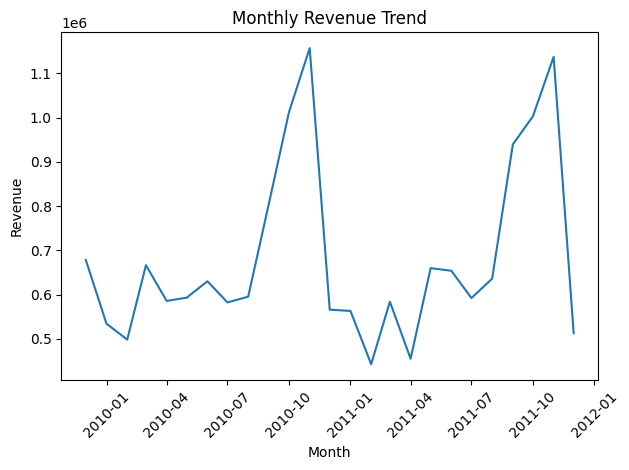

In [26]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(monthly_rev['month'], monthly_rev['revenue'])

plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Dec 2011 is incomplete — dataset ends 9th Dec. MoM drop of -54% is not a real decline

In [27]:
duckdb.sql("""
WITH monthly_rev AS (
  SELECT
    DATE_TRUNC('month',InvoiceDate) as month,
    ROUND(SUM(TotalPrice),2) as revenue
  FROM df
  WHERE InvoiceDate < '2011-12-01'
  GROUP BY month
)

SELECT
  month,
  revenue,
  ROUND((revenue-LAG(revenue) OVER(ORDER BY month))*100/LAG(revenue) OVER(ORDER BY month),2) as MoM
FROM monthly_rev
ORDER BY month
""").show()

┌────────────┬────────────┬────────┐
│   month    │  revenue   │  MoM   │
│    date    │   double   │ double │
├────────────┼────────────┼────────┤
│ 2009-12-01 │  678394.57 │   NULL │
│ 2010-01-01 │  533952.98 │ -21.29 │
│ 2010-02-01 │  498152.58 │   -6.7 │
│ 2010-03-01 │  666373.67 │  33.77 │
│ 2010-04-01 │  585544.93 │ -12.13 │
│ 2010-05-01 │  592964.13 │   1.27 │
│ 2010-06-01 │  630020.45 │   6.25 │
│ 2010-07-01 │  582207.96 │  -7.59 │
│ 2010-08-01 │  595141.17 │   2.22 │
│ 2010-09-01 │  805974.81 │  35.43 │
│     ·      │      ·     │    ·   │
│     ·      │      ·     │    ·   │
│     ·      │      ·     │    ·   │
│ 2011-02-01 │  442493.59 │ -21.39 │
│ 2011-03-01 │  583843.85 │  31.94 │
│ 2011-04-01 │  454855.88 │ -22.09 │
│ 2011-05-01 │  659693.49 │  45.03 │
│ 2011-06-01 │  653764.92 │   -0.9 │
│ 2011-07-01 │  592103.79 │  -9.43 │
│ 2011-08-01 │  635864.38 │   7.39 │
│ 2011-09-01 │  939682.63 │  47.78 │
│ 2011-10-01 │ 1003056.56 │   6.74 │
│ 2011-11-01 │  1137664.0 │  13.42 │
├

In [28]:
duckdb.sql("""
  SELECT
    EXTRACT(MONTH FROM InvoiceDate) as month,
    ROUND(SUM(TotalPrice),2) as revenue,
    ROUND(SUM(TotalPrice)*100/SUM(SUM(TotalPrice)) OVER(),2) AS rev_pct
  FROM df
  WHERE InvoiceDate < '2011-12-01'
  GROUP BY month
  ORDER BY month
""").show()

┌───────┬────────────┬─────────┐
│ month │  revenue   │ rev_pct │
│ int64 │   double   │ double  │
├───────┼────────────┼─────────┤
│     1 │ 1096850.89 │    6.62 │
│     2 │  940646.17 │    5.68 │
│     3 │ 1250217.52 │    7.55 │
│     4 │ 1040400.81 │    6.28 │
│     5 │ 1252657.62 │    7.56 │
│     6 │ 1283785.37 │    7.75 │
│     7 │ 1174311.75 │    7.09 │
│     8 │ 1231005.55 │    7.43 │
│     9 │ 1745657.44 │   10.53 │
│    10 │ 2015478.06 │   12.16 │
│    11 │ 2294972.39 │   13.85 │
│    12 │ 1244159.13 │    7.51 │
├───────┴────────────┴─────────┤
│ 12 rows            3 columns │
└──────────────────────────────┘



In [29]:
duckdb.sql("""
  WITH monthly_metrics AS (
    SELECT
      DATE_TRUNC('month',InvoiceDate) as month,
      ROUND(SUM(TotalPrice),2) as revenue,
      COUNT(DISTINCT Invoice) as invoice_count,
      COUNT(DISTINCT "Customer ID") as customer_count
    FROM df
    WHERE InvoiceDate < '2011-12-01'
    GROUP BY month
)

SELECT
  month,
  revenue,
  invoice_count,
  customer_count,
  ROUND(revenue*1.0/customer_count,2) as rev_by_cust,
  ROUND(revenue*1.0/invoice_count,2) as AOV
FROM monthly_metrics
ORDER BY month

""").show()

┌────────────┬────────────┬───────────────┬────────────────┬─────────────┬────────┐
│   month    │  revenue   │ invoice_count │ customer_count │ rev_by_cust │  AOV   │
│    date    │   double   │     int64     │     int64      │   double    │ double │
├────────────┼────────────┼───────────────┼────────────────┼─────────────┼────────┤
│ 2009-12-01 │  678394.57 │          1503 │            952 │       712.6 │ 451.36 │
│ 2010-01-01 │  533952.98 │           963 │            702 │      760.62 │ 554.47 │
│ 2010-02-01 │  498152.58 │          1094 │            771 │      646.11 │ 455.35 │
│ 2010-03-01 │  666373.67 │          1509 │           1051 │      634.04 │  441.6 │
│ 2010-04-01 │  585544.93 │          1319 │            941 │      622.26 │ 443.93 │
│ 2010-05-01 │  592964.13 │          1367 │            965 │      614.47 │ 433.77 │
│ 2010-06-01 │  630020.45 │          1484 │           1036 │      608.13 │ 424.54 │
│ 2010-07-01 │  582207.96 │          1368 │            926 │      628.73 │ 4

In [30]:
duckdb.sql("""
  WITH country_rev as (
    SELECT Country,
      SUM(TotalPrice) as revenue
    FROM df
    GROUP BY Country
  )
  SELECT
    CAST(Country AS VARCHAR) as Country,
    ROUND(revenue,2),
    ROUND(revenue*100.0/SUM(revenue) OVER(),2) as rev_contribution
  FROM country_rev
  ORDER BY rev_contribution DESC LIMIT 5
""")

┌────────────────┬───────────────────┬──────────────────┐
│    Country     │ round(revenue, 2) │ rev_contribution │
│    varchar     │      double       │      double      │
├────────────────┼───────────────────┼──────────────────┤
│ United Kingdom │       14293040.57 │            83.67 │
│ EIRE           │         595616.08 │             3.49 │
│ Netherlands    │         549773.41 │             3.22 │
│ Germany        │          383289.0 │             2.24 │
│ France         │         309799.16 │             1.81 │
└────────────────┴───────────────────┴──────────────────┘

In [31]:
duckdb.sql("""
WITH country_revenue as (
    SELECT
      Country,
      SUM(TotalPrice) AS Revenue
    FROM df
    GROUP BY Country
),
metrics as (
  SELECT Country,
    ROUND(Revenue,2) as revenue,
    ROUND(revenue*100.0/SUM(revenue) OVER(),2) as rev_contribution
  FROM country_revenue
)
SELECT
  Cast(Country as Varchar) as Country,
  revenue,
  rev_contribution
FROM metrics
WHERE Country!='United Kingdom'
ORDER BY revenue DESC
LIMIT 5
""").show()

┌─────────────┬───────────┬──────────────────┐
│   Country   │  revenue  │ rev_contribution │
│   varchar   │  double   │      double      │
├─────────────┼───────────┼──────────────────┤
│ EIRE        │ 595616.08 │             3.49 │
│ Netherlands │ 549773.41 │             3.22 │
│ Germany     │  383289.0 │             2.24 │
│ France      │ 309799.16 │             1.81 │
│ Australia   │ 167800.01 │             0.98 │
└─────────────┴───────────┴──────────────────┘



In [32]:
duckdb.sql("""
WITH yearly_metrics as(
  SELECT
    EXTRACT(year FROM InvoiceDate) as year,
    ROUND(SUM(TotalPrice),2) as revenue,
    COUNT(DISTINCT EXTRACT(month FROM InvoiceDate)) as month_cnt,
    COUNT(DISTINCT Invoice) as invoice_count,
    COUNT(DISTINCT "Customer ID") as cust_count
  FROM df
  WHERE EXTRACT(month FROM InvoiceDate)!=12
  GROUP BY year
)

SELECT
  year,
  revenue,
  month_cnt,
  invoice_count,
  cust_count,
  ROUND(100*(revenue-LAG(revenue) OVER(ORDER BY year))/LAG(revenue) OVER(ORDER BY year),2) as YoY
FROM yearly_metrics
ORDER BY year

""").show()

┌───────┬────────────┬───────────┬───────────────┬────────────┬────────┐
│ year  │  revenue   │ month_cnt │ invoice_count │ cust_count │  YoY   │
│ int64 │   double   │   int64   │     int64     │   int64    │ double │
├───────┼────────────┼───────────┼───────────────┼────────────┼────────┤
│  2010 │ 7660062.57 │        11 │         16724 │       4128 │   NULL │
│  2011 │  7665921.0 │        11 │         16243 │       4168 │   0.08 │
└───────┴────────────┴───────────┴───────────────┴────────────┴────────┘



**RFM ANALYSIS**

In [33]:
duckdb.sql("""
  SELECT
    CAST(MAX(InvoiceDate) AS DATE) as date
  FROM df
""").show()

┌────────────┐
│    date    │
│    date    │
├────────────┤
│ 2011-12-09 │
└────────────┘



Reference date is 2011-12-09 — last transaction date in dataset. Recency calculated as days since last purchase from this date.

In [34]:
rfm_df=duckdb.sql("""
  WITH cust_rfm AS(
    SELECT
      "Customer ID",
      DATEDIFF('day',CAST(MAX(InvoiceDate) AS DATE),'2011-12-09') AS recency,
      COUNT(DISTINCT Invoice) as frequency,
      ROUND(SUM(TotalPrice),2) as monetary
    FROM df
    GROUP BY "Customer ID"
  ),
  rfm_score AS(
    SELECT *,
      NTILE(5) OVER(ORDER BY recency DESC) AS r_score,
      NTILE(5) OVER(ORDER BY frequency ASC) AS f_score,
      NTILE(5) OVER(ORDER BY monetary ASC) AS m_score
    FROM cust_rfm
  )
SELECT *,
  CASE
    WHEN r_score>=4 AND f_score>=4 AND m_score>=4 THEN 'Champions'
    WHEN r_score<=2 AND f_score>=3 THEN 'At Risk'
    WHEN r_score>=3 AND f_score<=2 THEN 'Needs Attention'
    WHEN f_score>=3 AND m_score>=3 THEN 'Loyal'
    ELSE 'Lost'
  END AS segment
FROM rfm_score
""").df()
rfm_df.head()

,Customer ID,recency,frequency,monetary,r_score,f_score,m_score,segment
0,14095,722,1,2.95,1,1,1,Lost
1,13788,505,1,3.75,1,1,1,Lost
2,16738,297,1,3.75,2,1,1,Lost
3,14792,63,1,6.20,3,2,1,Needs Attention
4,15913,534,1,6.30,1,1,1,Lost


In [35]:
duckdb.sql("""
    SELECT
        ROUND(AVG(recency), 1) AS avg_days,
        MEDIAN(recency) AS median_days,
        QUANTILE_CONT(recency, 0.25) AS p25_fast,
        QUANTILE_CONT(recency, 0.75) AS p75_slow,
        QUANTILE_CONT(recency, 0.90) AS p90_critical
    FROM rfm_df
""").show()

┌──────────┬─────────────┬──────────┬──────────┬──────────────┐
│ avg_days │ median_days │ p25_fast │ p75_slow │ p90_critical │
│  double  │   double    │  double  │  double  │    double    │
├──────────┼─────────────┼──────────┼──────────┼──────────────┤
│    199.7 │        95.0 │     25.0 │    379.0 │        530.0 │
└──────────┴─────────────┴──────────┴──────────┴──────────────┘



In [36]:
duckdb.sql("""
  SELECT
    segment,
    "Customer ID",
    monetary,
    recency,
    CASE
      WHEN recency <= 25 THEN 'Active (Top 25%)'
      WHEN recency <= 95 THEN 'Active (Median)'
      ELSE 'Lapsed'
    END AS activity_status
  FROM rfm_df
  ORDER BY monetary DESC
  LIMIT 10
""").show()



┌───────────┬─────────────┬───────────┬─────────┬──────────────────┐
│  segment  │ Customer ID │ monetary  │ recency │ activity_status  │
│  varchar  │    int64    │  double   │  int64  │     varchar      │
├───────────┼─────────────┼───────────┼─────────┼──────────────────┤
│ Champions │       18102 │ 580987.04 │       0 │ Active (Top 25%) │
│ Champions │       14646 │ 526751.52 │       1 │ Active (Top 25%) │
│ Champions │       14156 │ 304719.88 │       9 │ Active (Top 25%) │
│ Champions │       14911 │ 279492.79 │       1 │ Active (Top 25%) │
│ Champions │       17450 │ 244784.25 │       8 │ Active (Top 25%) │
│ Champions │       13694 │ 195640.69 │       3 │ Active (Top 25%) │
│ Champions │       17511 │ 172132.87 │       2 │ Active (Top 25%) │
│ Loyal     │       16446 │  168472.5 │       0 │ Active (Top 25%) │
│ Champions │       16684 │ 147142.77 │       4 │ Active (Top 25%) │
│ Champions │       12415 │ 144033.37 │      24 │ Active (Top 25%) │
├───────────┴─────────────┴───────

*Champions are 22% of customers but generate 68% of revenue. Lost segment is the largest group at 33% but contributes only 4.77% of revenue.*

In [37]:
seg_cust_dst=duckdb.sql("""
  SELECT
    segment,
    COUNT(*) AS cust_count,
    ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(),2) AS pct_cust
  FROM rfm_df
  GROUP BY segment
""").df()
seg_cust_dst.head()

,segment,cust_count,pct_cust
0,Loyal,1152,19.68
1,Champions,1330,22.72
2,Lost,1951,33.33
3,Needs Attention,710,12.13
4,At Risk,710,12.13


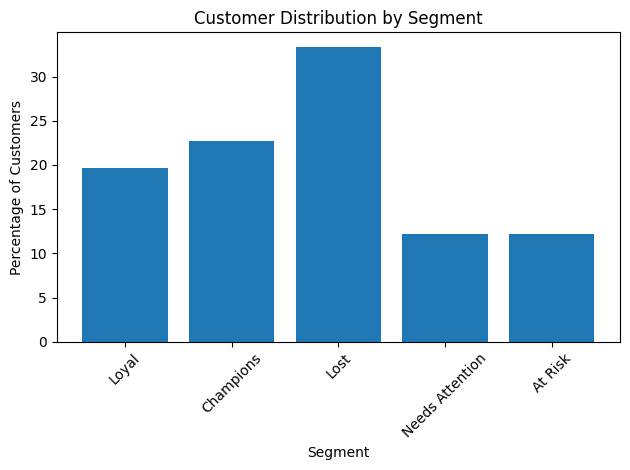

In [38]:
plt.figure()
plt.bar(seg_cust_dst['segment'],seg_cust_dst['pct_cust'])

plt.xlabel('Segment')
plt.ylabel('Percentage of Customers')
plt.title('Customer Distribution by Segment')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
seg_rev_dst=duckdb.sql("""
  SELECT
    segment,
    ROUND(SUM(monetary),2) as monetary,
    ROUND(SUM(monetary)*100.0/SUM(SUM(monetary)) OVER(),2) AS pct_monetary
  FROM rfm_df
  GROUP BY segment
""").df()
seg_rev_dst

,segment,monetary,pct_monetary
0,Loyal,2654670.64,15.54
1,Champions,11740226.78,68.73
2,Lost,814944.09,4.77
3,Needs Attention,342404.72,2.00
4,At Risk,1530289.54,8.96


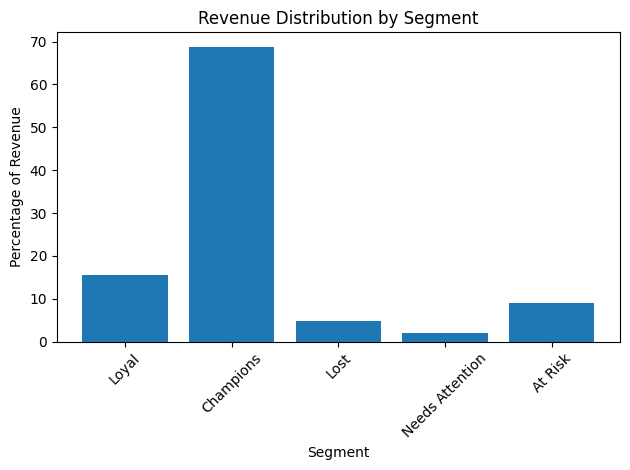

In [40]:
plt.figure()
plt.bar(seg_rev_dst['segment'],seg_rev_dst['pct_monetary'])

plt.xlabel('Segment')
plt.ylabel('Percentage of Revenue')
plt.title('Revenue Distribution by Segment')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Customers inactive 180+ days with above-average spend — primary win-back targets. At Risk segment dominates this list.

In [41]:
duckdb.sql("""
  SELECT
    segment,
    "Customer ID",
    monetary,
    recency
  FROM rfm_df
  WHERE recency>=180
    AND monetary> (SELECT AVG(monetary) from rfm_df)
  ORDER BY monetary DESC
  LIMIT 10
""").show()

┌─────────┬─────────────┬──────────┬─────────┐
│ segment │ Customer ID │ monetary │ recency │
│ varchar │    int64    │  double  │  int64  │
├─────────┼─────────────┼──────────┼─────────┤
│ At Risk │       12346 │ 77556.46 │     325 │
│ At Risk │       16754 │ 65500.07 │     372 │
│ At Risk │       13093 │ 54144.25 │     275 │
│ At Risk │       17850 │ 51208.87 │     372 │
│ At Risk │       15749 │  44534.3 │     235 │
│ Loyal   │       15098 │  39916.5 │     182 │
│ At Risk │       13902 │ 34023.26 │     632 │
│ At Risk │       12482 │ 21941.72 │     576 │
│ At Risk │       15808 │ 17180.25 │     306 │
│ At Risk │       13564 │ 15880.22 │     354 │
├─────────┴─────────────┴──────────┴─────────┤
│ 10 rows                          4 columns │
└────────────────────────────────────────────┘



Customer base is split almost evenly — 28% bought within 30 days, 27% haven't bought in over a year. Retention is the core problem.

In [42]:
duckdb.sql("""
  SELECT
    CASE
      WHEN recency <= 30 THEN '0-30 days'
      WHEN recency <= 90 THEN '31-90 days'
      WHEN recency <= 180 THEN '91-180 days'
      WHEN recency <= 365 THEN '181-365 days'
      ELSE '365+ days'
    END AS recency_bucket,
    COUNT(*) AS cust_count,
    ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(),2) AS pct
  FROM rfm_df
  GROUP BY recency_bucket
  ORDER BY MIN(recency)
""").show()

┌────────────────┬────────────┬────────┐
│ recency_bucket │ cust_count │  pct   │
│    varchar     │   int64    │ double │
├────────────────┼────────────┼────────┤
│ 0-30 days      │       1666 │  28.46 │
│ 31-90 days     │       1220 │  20.84 │
│ 91-180 days    │        589 │  10.06 │
│ 181-365 days   │        796 │   13.6 │
│ 365+ days      │       1582 │  27.03 │
└────────────────┴────────────┴────────┘



**COHORT ANALYSIS**

In [43]:
cohort_df = duckdb.sql("""
  WITH customer_cohort AS (
    SELECT
      "Customer ID",
      DATE_TRUNC('month', MIN(InvoiceDate)) AS cohort_month
    FROM df
    GROUP BY "Customer ID"
  ),
  monthly_activity AS (
    SELECT
      d."Customer ID",
      DATE_TRUNC('month', d.InvoiceDate) AS activity_month
    FROM df d
    GROUP BY d."Customer ID", activity_month
  )
  SELECT
    c.cohort_month,
    a.activity_month,
    DATEDIFF('month', c.cohort_month, a.activity_month) AS period,
    COUNT(DISTINCT a."Customer ID") AS customers
  FROM customer_cohort c
  JOIN monthly_activity a ON c."Customer ID" = a."Customer ID"
  GROUP BY c.cohort_month, a.activity_month
  ORDER BY c.cohort_month, period
""").df()
cohort_df.head()

,cohort_month,activity_month,period,customers
0,2009-12-01,2009-12-01,0,952
1,2009-12-01,2010-01-01,1,334
2,2009-12-01,2010-02-01,2,317
3,2009-12-01,2010-03-01,3,405
4,2009-12-01,2010-04-01,4,362


In [44]:
cohort_retention_df = duckdb.sql("""
  WITH cohort_size AS (
    SELECT cohort_month, customers AS total_customers
    FROM cohort_df WHERE period = 0
  )
  SELECT
    c.cohort_month,
    c.period,
    c.customers,
    cs.total_customers,
    ROUND(c.customers * 100.0 / cs.total_customers, 2) AS retention_rate
  FROM cohort_df c
  JOIN cohort_size cs ON c.cohort_month = cs.cohort_month
  ORDER BY c.cohort_month, c.period
""").df()
cohort_retention_df.head()

,cohort_month,period,customers,total_customers,retention_rate
0,2009-12-01,0,952,952,100.00
1,2009-12-01,1,334,952,35.08
2,2009-12-01,2,317,952,33.30
3,2009-12-01,3,405,952,42.54
4,2009-12-01,4,362,952,38.03


In [45]:
duckdb.sql("""
  SELECT cohort_month,period,retention_rate FROM cohort_retention_df
  WHERE period IN(3,6,12)
  ORDER BY cohort_month,period
""").show()

┌─────────────────────┬────────┬────────────────┐
│    cohort_month     │ period │ retention_rate │
│      timestamp      │ int64  │     double     │
├─────────────────────┼────────┼────────────────┤
│ 2009-12-01 00:00:00 │      3 │          42.54 │
│ 2009-12-01 00:00:00 │      6 │          37.82 │
│ 2009-12-01 00:00:00 │     12 │          37.71 │
│ 2010-01-01 00:00:00 │      3 │          31.52 │
│ 2010-01-01 00:00:00 │      6 │           26.9 │
│ 2010-01-01 00:00:00 │     12 │          22.83 │
│ 2010-02-01 00:00:00 │      3 │          29.33 │
│ 2010-02-01 00:00:00 │      6 │           19.2 │
│ 2010-02-01 00:00:00 │     12 │           15.2 │
│ 2010-03-01 00:00:00 │      3 │          24.09 │
│          ·          │      · │            ·   │
│          ·          │      · │            ·   │
│          ·          │      · │            ·   │
│ 2011-03-01 00:00:00 │      6 │          20.67 │
│ 2011-04-01 00:00:00 │      3 │          19.81 │
│ 2011-04-01 00:00:00 │      6 │          17.92 │


In [46]:
duckdb.sql("""
  SELECT cohort_month :: Date, period, customers, total_customers, retention_rate
  FROM cohort_retention_df
  ORDER BY cohort_month, period
""").show()

┌────────────────────────────┬────────┬───────────┬─────────────────┬────────────────┐
│ CAST(cohort_month AS DATE) │ period │ customers │ total_customers │ retention_rate │
│            date            │ int64  │   int64   │      int64      │     double     │
├────────────────────────────┼────────┼───────────┼─────────────────┼────────────────┤
│ 2009-12-01                 │      0 │       952 │             952 │          100.0 │
│ 2009-12-01                 │      1 │       334 │             952 │          35.08 │
│ 2009-12-01                 │      2 │       317 │             952 │           33.3 │
│ 2009-12-01                 │      3 │       405 │             952 │          42.54 │
│ 2009-12-01                 │      4 │       362 │             952 │          38.03 │
│ 2009-12-01                 │      5 │       342 │             952 │          35.92 │
│ 2009-12-01                 │      6 │       360 │             952 │          37.82 │
│ 2009-12-01                 │      7 │    

In [47]:
duckdb.sql("""
  SELECT
    STRFTIME(cohort_month :: DATE, '%Y-%m') AS cohort,
    total_customers AS acquired,
    MAX(CASE WHEN period = 1 THEN retention_rate END) AS month_1,
    MAX(CASE WHEN period = 3 THEN retention_rate END) AS month_3,
    MAX(CASE WHEN period = 6 THEN retention_rate END) AS month_6,
    MAX(CASE WHEN period = 12 THEN retention_rate END) AS month_12
  FROM cohort_retention_df
  GROUP BY cohort_month, total_customers
  ORDER BY cohort_month
""").show()

┌─────────┬──────────┬─────────┬─────────┬─────────┬──────────┐
│ cohort  │ acquired │ month_1 │ month_3 │ month_6 │ month_12 │
│ varchar │  int64   │ double  │ double  │ double  │  double  │
├─────────┼──────────┼─────────┼─────────┼─────────┼──────────┤
│ 2009-12 │      952 │   35.08 │   42.54 │   37.82 │    37.71 │
│ 2010-01 │      368 │   21.47 │   31.52 │    26.9 │    22.83 │
│ 2010-02 │      375 │   23.47 │   29.33 │    19.2 │     15.2 │
│ 2010-03 │      440 │   19.09 │   24.09 │    25.0 │     20.0 │
│ 2010-04 │      294 │   19.05 │   15.99 │   27.55 │    14.29 │
│ 2010-05 │      255 │   15.69 │   17.65 │   21.18 │    15.29 │
│ 2010-06 │      267 │    17.6 │    20.6 │   12.73 │    14.98 │
│ 2010-07 │      186 │   15.59 │   29.57 │   11.29 │     12.9 │
│ 2010-08 │      163 │   19.63 │   32.52 │    9.82 │    14.72 │
│ 2010-09 │      239 │   23.01 │   12.97 │   13.81 │    22.59 │
│    ·    │       ·  │     ·   │     ·   │     ·   │       ·  │
│    ·    │       ·  │     ·   │     ·  

In [48]:
duckdb.sql("""
  SELECT
    period,
    COUNT(cohort_month) AS cohort_count,
    ROUND(AVG(retention_rate), 2) AS avg_retention,
    ROUND(MIN(retention_rate), 2) AS min_retention,
    ROUND(MAX(retention_rate), 2) AS max_retention
  FROM cohort_retention_df
  WHERE period > 0
  GROUP BY period
  ORDER BY period
""").show()

┌────────┬──────────────┬───────────────┬───────────────┬───────────────┐
│ period │ cohort_count │ avg_retention │ min_retention │ max_retention │
│ int64  │    int64     │    double     │    double     │    double     │
├────────┼──────────────┼───────────────┼───────────────┼───────────────┤
│      1 │           24 │         20.99 │          9.21 │         35.08 │
│      2 │           23 │         21.93 │          5.26 │         37.77 │
│      3 │           22 │         21.71 │          9.21 │         42.54 │
│      4 │           21 │          20.6 │          7.67 │         38.03 │
│      5 │           20 │         18.88 │          6.58 │         35.92 │
│      6 │           19 │         17.94 │          5.26 │         37.82 │
│      7 │           18 │          17.8 │          8.99 │         34.35 │
│      8 │           17 │         15.73 │          5.26 │         33.72 │
│      9 │           16 │          15.3 │          2.63 │         36.13 │
│     10 │           15 │         15.0

In [49]:
duckdb.sql("""
  SELECT
    period,
    cohort_month :: date,
    retention_rate,
    RANK() OVER (PARTITION BY period ORDER BY retention_rate DESC) AS best_rank,
    RANK() OVER (PARTITION BY period ORDER BY retention_rate ASC) AS worst_rank
  FROM cohort_retention_df
  WHERE period IN (3, 6, 12)
  QUALIFY best_rank <= 2 OR worst_rank <= 2
  ORDER BY period, best_rank
""").show()

┌────────┬────────────────────────────┬────────────────┬───────────┬────────────┐
│ period │ CAST(cohort_month AS DATE) │ retention_rate │ best_rank │ worst_rank │
│ int64  │            date            │     double     │   int64   │   int64    │
├────────┼────────────────────────────┼────────────────┼───────────┼────────────┤
│      3 │ 2009-12-01                 │          42.54 │         1 │         22 │
│      3 │ 2010-08-01                 │          32.52 │         2 │         21 │
│      3 │ 2010-11-01                 │           9.51 │        21 │          2 │
│      3 │ 2010-12-01                 │           9.21 │        22 │          1 │
│      6 │ 2009-12-01                 │          37.82 │         1 │         19 │
│      6 │ 2010-04-01                 │          27.55 │         2 │         18 │
│      6 │ 2011-06-01                 │           8.33 │        18 │          2 │
│      6 │ 2010-12-01                 │           5.26 │        19 │          1 │
│     12 │ 2009-

In [50]:
duckdb.sql("""
  SELECT
    STRFTIME(cohort_month :: DATE, '%Y-%m') AS cohort,
    total_customers AS acquired,
    MAX(CASE WHEN period = 12 THEN customers END) AS surviving_12m,
    ROUND(MAX(CASE WHEN period = 12 THEN customers END) * 100.0 / total_customers, 2) AS retention_pct_12m
  FROM cohort_retention_df
  WHERE cohort_month <= '2010-12-01'
  GROUP BY cohort_month, total_customers
  ORDER BY cohort_month
""").show()

┌─────────┬──────────┬───────────────┬───────────────────┐
│ cohort  │ acquired │ surviving_12m │ retention_pct_12m │
│ varchar │  int64   │     int64     │      double       │
├─────────┼──────────┼───────────────┼───────────────────┤
│ 2009-12 │      952 │           359 │             37.71 │
│ 2010-01 │      368 │            84 │             22.83 │
│ 2010-02 │      375 │            57 │              15.2 │
│ 2010-03 │      440 │            88 │              20.0 │
│ 2010-04 │      294 │            42 │             14.29 │
│ 2010-05 │      255 │            39 │             15.29 │
│ 2010-06 │      267 │            40 │             14.98 │
│ 2010-07 │      186 │            24 │              12.9 │
│ 2010-08 │      163 │            24 │             14.72 │
│ 2010-09 │      239 │            54 │             22.59 │
│ 2010-10 │      375 │            72 │              19.2 │
│ 2010-11 │      326 │            83 │             25.46 │
│ 2010-12 │       76 │             2 │              2.63

In [51]:
duckdb.sql("""
  SELECT
    period,
    ROUND(AVG(retention_rate), 2) AS avg_retention,
    ROUND(AVG(retention_rate) - LAG(AVG(retention_rate)) OVER (ORDER BY period), 2) AS drop_from_prev
  FROM cohort_retention_df
  WHERE period > 0
  GROUP BY period
  ORDER BY period
""").show()

┌────────┬───────────────┬────────────────┐
│ period │ avg_retention │ drop_from_prev │
│ int64  │    double     │     double     │
├────────┼───────────────┼────────────────┤
│      1 │         20.99 │           NULL │
│      2 │         21.93 │           0.94 │
│      3 │         21.71 │          -0.22 │
│      4 │          20.6 │          -1.11 │
│      5 │         18.88 │          -1.72 │
│      6 │         17.94 │          -0.94 │
│      7 │          17.8 │          -0.13 │
│      8 │         15.73 │          -2.08 │
│      9 │          15.3 │          -0.43 │
│     10 │         15.07 │          -0.23 │
│      · │           ·   │             ·  │
│      · │           ·   │             ·  │
│      · │           ·   │             ·  │
│     15 │         16.56 │           0.83 │
│     16 │         17.34 │           0.77 │
│     17 │         17.79 │           0.45 │
│     18 │         16.85 │          -0.93 │
│     19 │         19.47 │           2.62 │
│     20 │         20.15 │      

*dec 2009 cohort strongest throughout — earliest customers stayed longest. dec 2010 worst at 2.63% by month 12, likely one-time gift buyers. retention settles around 15-21% after month 7 — whoever stays past that tends to stick around.*

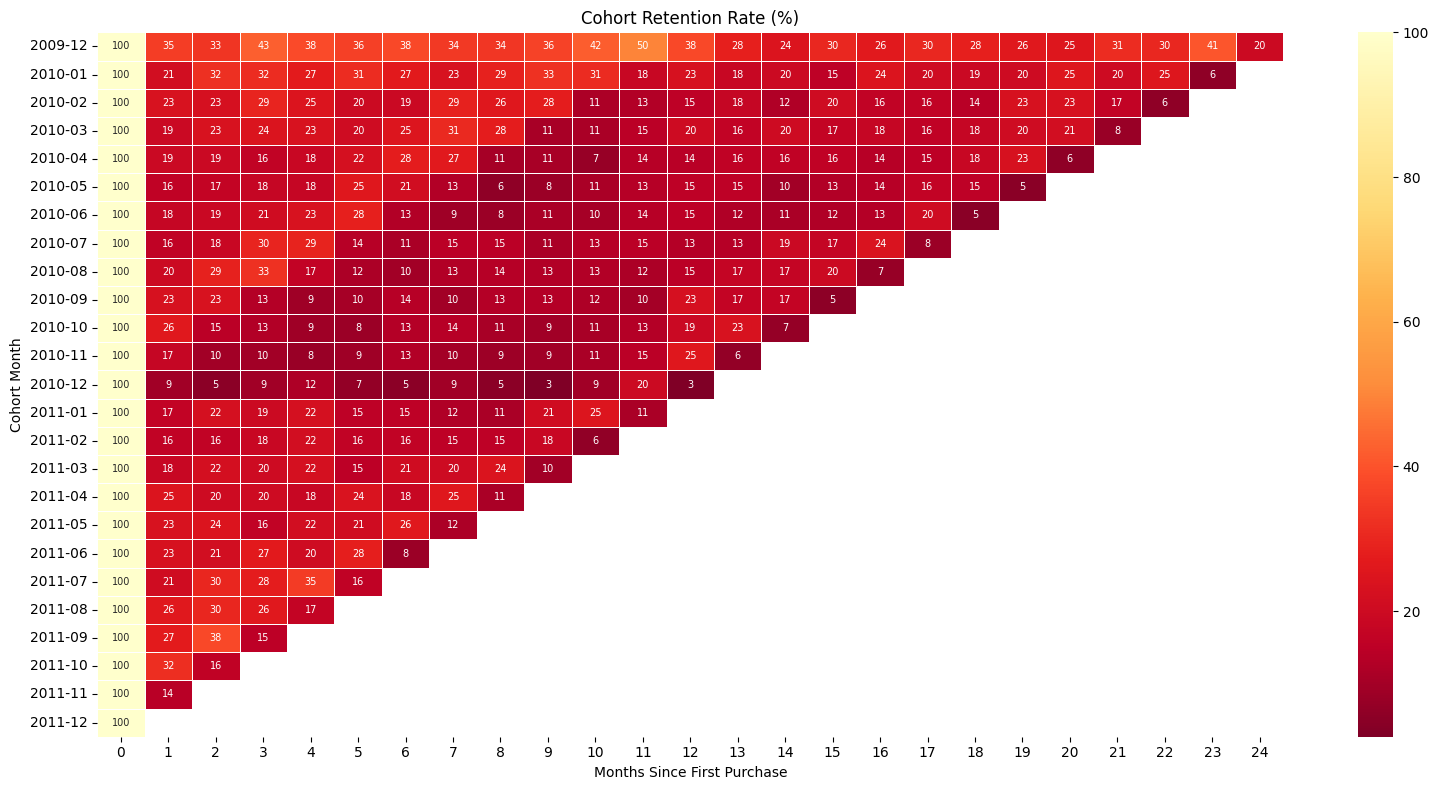

In [52]:
import seaborn as sns

cohort_pivot = cohort_retention_df.pivot_table(
    index='cohort_month',
    columns='period',
    values='retention_rate'
)

cohort_pivot.index = cohort_pivot.index.astype(str).str[:7]

plt.figure(figsize=(16, 8))
sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    annot_kws={'size': 7}
)

plt.title('Cohort Retention Rate (%)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

**Simple CLV — avg order value × monthly purchase rate × 12**

In [53]:
clv_df = duckdb.sql("""
  WITH customer_metrics AS (
    SELECT
      "Customer ID",
      COUNT(DISTINCT Invoice) AS total_orders,
      ROUND(SUM(TotalPrice), 2) AS total_revenue,
      CASE
        WHEN DATEDIFF('month', CAST(MIN(InvoiceDate) AS DATE),CAST(MAX(InvoiceDate) AS DATE)) = 0 THEN 1
        ELSE DATEDIFF('month',CAST(MIN(InvoiceDate) AS DATE),CAST(MAX(InvoiceDate) AS DATE))
      END AS active_months
    FROM df
    GROUP BY "Customer ID"
  ),
  customer_clv AS (
    SELECT
      c."Customer ID",
      r.segment,
      c.total_orders,
      c.total_revenue,
      c.active_months,
      ROUND(c.total_revenue / c.total_orders, 2) AS avg_order_value,
      ROUND(c.total_orders * 1.0 / c.active_months, 2) AS purchase_rate
    FROM customer_metrics c
    JOIN rfm_df r ON c."Customer ID" = r."Customer ID"
  )
  SELECT *,
    ROUND(avg_order_value * purchase_rate * 12, 2) AS clv_12m
  FROM customer_clv
""").df()
clv_df.head()

,Customer ID,segment,total_orders,total_revenue,active_months,avg_order_value,purchase_rate,clv_12m
0,13085,Loyal,8,2433.28,19,304.16,0.42,1532.97
1,13078,Champions,57,29018.06,24,509.09,2.38,14539.61
2,15362,Lost,2,613.08,9,306.54,0.22,809.27
3,18102,Champions,145,580987.04,24,4006.81,6.04,290413.59
4,14110,Champions,33,12987.95,24,393.57,1.38,6517.52


*champions have highest avg CLV at £5,943 — makes sense. but lost segment purchase rate is almost same as champions which is a formula limitation — lost customers had decent history before going inactive, formula doesn't know they've churned. at risk segment is the real focus — still reachable, decent spend history.*

In [54]:
duckdb.sql("""
  SELECT
    segment,
    COUNT(*) AS customers,
    ROUND(AVG(avg_order_value), 2) AS avg_order_value,
    ROUND(AVG(purchase_rate), 2) AS avg_purchase_rate,
    ROUND(AVG(clv_12m), 2) AS avg_clv_12m,
    ROUND(SUM(clv_12m), 2) AS total_clv_12m
  FROM clv_df
  GROUP BY segment
  ORDER BY avg_clv_12m DESC
""").show()

┌─────────────────┬───────────┬─────────────────┬───────────────────┬─────────────┬───────────────┐
│     segment     │ customers │ avg_order_value │ avg_purchase_rate │ avg_clv_12m │ total_clv_12m │
│     varchar     │   int64   │     double      │      double       │   double    │    double     │
├─────────────────┼───────────┼─────────────────┼───────────────────┼─────────────┼───────────────┤
│ Champions       │      1330 │          449.96 │              0.96 │     5946.89 │    7909368.45 │
│ At Risk         │       710 │           364.6 │              0.92 │     4410.01 │    3131107.53 │
│ Needs Attention │       710 │          368.16 │              0.92 │     3969.74 │    2818512.41 │
│ Loyal           │      1152 │          462.57 │              0.62 │     3554.54 │    4094828.23 │
│ Lost            │      1951 │           296.5 │              0.93 │     3422.21 │    6676730.59 │
└─────────────────┴───────────┴─────────────────┴───────────────────┴─────────────┴───────────────┘


In [55]:
duckdb.sql("""
  SELECT
    segment,
    ROUND(AVG(purchase_rate), 2) AS avg_orders_per_month,
    ROUND(MIN(purchase_rate), 2) AS min_rate,
    ROUND(MAX(purchase_rate), 2) AS max_rate,
    ROUND(MEDIAN(purchase_rate), 2) AS median_rate
  FROM clv_df
  GROUP BY segment
  ORDER BY avg_orders_per_month DESC
""").show()

┌─────────────────┬──────────────────────┬──────────┬──────────┬─────────────┐
│     segment     │ avg_orders_per_month │ min_rate │ max_rate │ median_rate │
│     varchar     │        double        │  double  │  double  │   double    │
├─────────────────┼──────────────────────┼──────────┼──────────┼─────────────┤
│ Champions       │                 0.96 │     0.17 │    15.67 │        0.65 │
│ Lost            │                 0.93 │     0.09 │      4.0 │         1.0 │
│ At Risk         │                 0.92 │     0.19 │    12.92 │        0.57 │
│ Needs Attention │                 0.92 │     0.09 │      2.0 │         1.0 │
│ Loyal           │                 0.62 │     0.09 │      5.0 │        0.42 │
└─────────────────┴──────────────────────┴──────────┴──────────┴─────────────┘

